## Reinforcement Learning, LETSSSS GOOOOOO

Ok, so what is reinforcement learning? It's a type of machine learning where an agent learns by trying, if he does something good he gets a reward, if he does something bad he gets a punishment. The goal of the agent is to maximize the total reward it receives over time.

This lab we have to make the fiamouse game: The Cliff Walker's Dilemma. An agen must traverse a grid world from a start state to a goal state while avoiding cliffs. The agent receives a reward of -1 for each step taken, and a reward of -100 for falling off the cliff. The agent receives a reward of +100 for reaching the goal state.

Let's start with the grid!

In [1]:
import numpy as np

class CliffWalkingEnv:
	UP = 0
	DOWN = 1
	LEFT = 2
	RIGHT = 3

	@staticmethod
	def __generate_grid(rows, cols):
		grid = np.zeros((rows, cols), dtype=int)
		grid[3, 1:11] = 1  		# Cliff
		grid[3, 0] = 0         	# Start
		return grid

	def __init__(self, rows=4, cols=12, normal_step_reward=-1, decay: bool = False):
		self.rows = rows
		self.cols = cols
		self.normal_step_reward = normal_step_reward
		self.decay = decay

		self.start_state = (3, 0)
		self.goal_state = (3, 11)

		self.grid = self.__generate_grid(self.rows, self.cols)

	def render(self):
		for r in range(self.rows):
			for c in range(self.cols):
				if (r, c) == self.start_state:
					print('S', end=' ')
				elif (r, c) == self.goal_state:
					print('G', end=' ')
				elif self.grid[r, c] == 1:
					print('C', end=' ')
				else:
					print('.', end=' ')
			print()

	def reset(self):
		self.agent_position = self.start_state
		return self.agent_position
	
	def step(self, action):
		r, c = self.agent_position

		if action == self.UP:
			r = max(r - 1, 0)
		elif action == self.DOWN:
			r = min(r + 1, self.rows - 1)
		elif action == self.LEFT:
			c = max(c - 1, 0)
		elif action == self.RIGHT:
			c = min(c + 1, self.cols - 1)

		self.agent_position = (r, c)

		if self.grid[r, c] == 1:  # Cliff
			reward = -100
			done = True

		elif (r, c) == self.goal_state:
			reward = 100
			done = True

		else:  # Normal step
			reward = self.normal_step_reward
			done = False

		return self.agent_position, reward, done
	
	def epsilon_greedy_policy(self, Q, state, epsilon):
		if self.decay:
			epsilon = max(0.001, epsilon - 0.001)  # Decay epsilon
		if np.random.rand() < epsilon:
			return np.random.choice(4)  # Random action
		else:
			return np.argmax(Q[state])  # Best action based on Q-values
		
	def q_learning_update(self, episodes = 100, alpha = 0.1, gamma = 0.9, epsilon = 0.1):
		Q = np.zeros((self.rows, self.cols, 4))  # Q-values
		reward_history = []

		for _ in range(episodes):
			state = self.reset()
			done = False
			total_reward = 0

			while not done:
				action = self.epsilon_greedy_policy(Q, state, epsilon)
				next_state, reward, done = self.step(action)
				total_reward += reward

				best_next_q = np.max(Q[next_state])
				Q[state][action] += alpha * (reward + gamma * best_next_q - Q[state][action])

				state = next_state

			reward_history.append(total_reward)

		return Q, reward_history
	
	def sarsa_update(self, episodes = 100, alpha = 0.1, gamma = 0.9, epsilon = 0.1):
		Q = np.zeros((self.rows, self.cols, 4))  # Q-values for each state-action pair
		reward_history = []

		for _ in range(episodes):
			state = self.reset()
			action = self.epsilon_greedy_policy(Q, state, epsilon)
			done = False
			total_reward = 0

			while not done:
				next_state, reward, done = self.step(action)
				total_reward += reward

				next_action = self.epsilon_greedy_policy(Q, next_state, epsilon)

				Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

				state = next_state
				action = next_action

			reward_history.append(total_reward)

		return Q, reward_history
	
	def extract_policy(self, Q):
		policy = np.zeros((self.rows, self.cols), dtype=int)
		for r in range(self.rows):
			for c in range(self.cols):
				policy[r, c] = np.argmax(Q[r, c])
		return policy
	
	def print_policy(self, policy):
		action_symbols = {self.UP: '↑', self.DOWN: '↓', self.LEFT: '←', self.RIGHT: '→'}
		for r in range(self.rows):
			for c in range(self.cols):
				if (r, c) == self.start_state:
					print('S', end=' ')
				elif (r, c) == self.goal_state:
					print('G', end=' ')
				elif self.grid[r, c] == 1:
					print('C', end=' ')
				else:
					print(action_symbols[policy[r, c]], end=' ')
			print()

In [89]:
agent = CliffWalkingEnv()
agent.render()

. . . . . . . . . . . . 
. . . . . . . . . . . . 
. . . . . . . . . . . . 
S C C C C C C C C C C G 


Now that we can see the grid let's understand with the Q-learning algorithm works.

### Q-learning
> [Q Learning Explained](https://www.youtube.com/watch?v=aCEvtRtNO-M&t=28s) <br>

Q-learning is a model-free learning technique that can be used to find the optimal action-selection policy using a Q-function.

First, the agent task is to learn a policy $\pi(a|s)$ that maximizes the comulative reward of future actions. We formalize this as the Markov Decision Process (MDP) which is defined by a tuple $(S, A, P, R, \gamma)$ where:
- $S$ is the set of states
- $A$ is the set of actions
- $P(s'|s, a)$ is the transition probability of going to state $s'$ from state $s$ by taking action $a$
- $R(s, a)$ is the reward received after taking action $a$ in state $s$
- $\gamma$ is the discount factor that determines the importance of future rewards

The Q-function, denoted as $Q(s, a)$, represents the expected cumulative reward of taking action $a$ in state $s$ and following the optimal policy thereafter. The Q-learning algorithm updates the Q-values using the following update rule:
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ R(s, a) + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a) \right]$$
where $\alpha$ is the learning rate that determines how much the Q-values are updated at each step.

In [90]:
Q_learn_values, Q_learn_rewards = agent.q_learning_update(episodes=500)

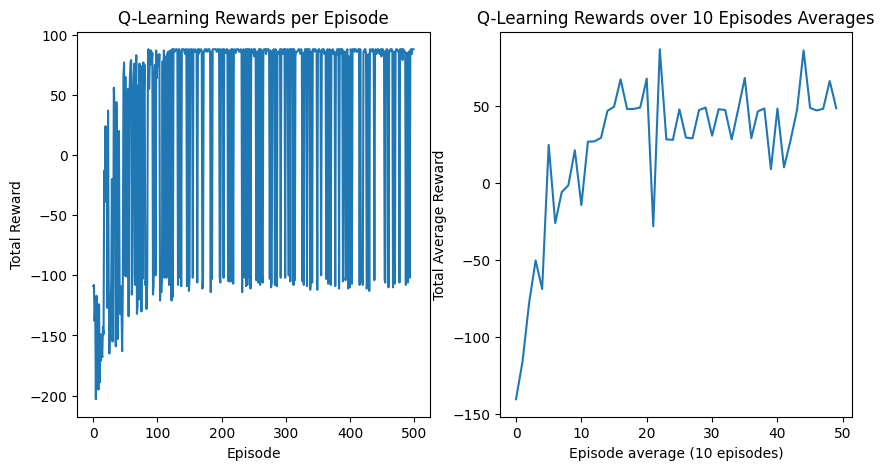

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(Q_learn_rewards)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Q-Learning Rewards per Episode')

axes[1].plot([np.average(Q_learn_rewards[index:index+10]) for index in range(0, len(Q_learn_rewards), 10)])
axes[1].set_xlabel('Episode average (10 episodes)')
axes[1].set_ylabel('Total Average Reward')
axes[1].set_title('Q-Learning Rewards over 10 Episodes Averages')

plt.show()

In [92]:
import pandas as pd

q_table = pd.DataFrame(Q_learn_values.reshape(-1, 4), columns=['UP', 'DOWN', 'LEFT', 'RIGHT'])
print(q_table)

           UP        DOWN       LEFT      RIGHT
0   -4.106778   -2.797896  -4.063683  -4.056466
1   -3.821339   -3.846275  -3.835063  -3.846428
2   -3.555385   -3.555136  -3.534789  -3.542910
3   -3.162054   -3.178648  -3.218318  -3.151138
4   -2.806391   -2.746595  -2.785625  -2.773123
5   -2.368329    0.455704  -2.345926  -2.332433
6   -1.891518   -1.838773  -1.958091  -1.862400
7   -1.399416   -0.887577  -1.422718  -1.403522
8   -0.955424   -0.960848  -0.987200  -0.964279
9   -0.585199   -0.625262  -0.652025  -0.684329
10  -0.393238   -0.408295  -0.441151  -0.447038
11  -0.297010    0.735429  -0.207910  -0.297010
12  -4.263450   12.386411  -4.215285  -3.258455
13  -3.915323   11.691904  -3.937652  -3.867209
14  -3.505738   11.207580  -2.458509  -3.475668
15  -3.089494   18.945660  -3.083146  -3.050245
16  -2.700931   -2.578251  -2.638652  10.534247
17  -2.167891   34.689868  -2.251597  -0.101748
18  -1.684308   -1.622601  -1.723663  17.957859
19  -1.249712   44.258598  -1.217598  -1

Why are there some columns with 0 on all rows?

### SARSA
> [Reinforcement Learning: on-policy vs off-policy algorithms](https://www.youtube.com/watch?v=YUKUXoUg3Nc&t=523s) <br>

What is SARSA? SARSA stands for State-Action-Reward-State-Action. It is an on-policy reinforcement learning algorithm that updates the Q-values based on the action taken by the agent in the next state. The update rule for SARSA is as follows:
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ R(s, a) + \gamma \cdot Q(s', a') - Q(s, a) \right]$$
where $a'$ is the action taken by the agent in the next state $s'$.

In [93]:
Q_saer_values, Q_saer_rewards = agent.sarsa_update(episodes=500)

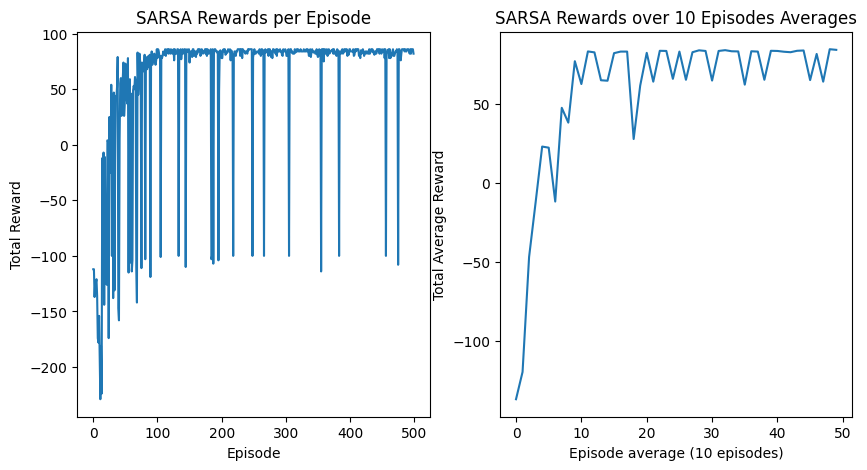

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(Q_saer_rewards)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('SARSA Rewards per Episode')

axes[1].plot([np.average(Q_saer_rewards[index:index+10]) for index in range(0, len(Q_saer_rewards), 10)])
axes[1].set_xlabel('Episode average (10 episodes)')
axes[1].set_ylabel('Total Average Reward')
axes[1].set_title('SARSA Rewards over 10 Episodes Averages')
plt.show()

In [95]:
saer_table = pd.DataFrame(Q_saer_values.reshape(-1, 4), columns=['UP', 'DOWN', 'LEFT', 'RIGHT'])
print(saer_table)

           UP        DOWN       LEFT      RIGHT
0   -4.768087    0.038842  -4.701778  -4.334405
1   -4.453354    2.057253  -4.463802  -4.423013
2   -4.132274    5.378914  -4.116979  -3.936921
3   -3.629947    3.026789  -3.684152  -2.424611
4   -1.995224   14.002858  -3.115571  -3.094517
5   -2.717926   -2.622157  -2.613076   8.987395
6    0.232935   22.710370  -1.449678  -2.092322
7   -1.592864   24.158950  -1.665482  -1.576095
8   -1.176064   23.405524  -1.098708  -0.506401
9   -0.746497   37.004427   2.055698  -0.731302
10  -0.376390   38.951246  -0.449277  -0.377200
11   3.958580   55.007298  -0.312392  -0.385948
12  -3.888674   -0.812248   1.269479   6.429772
13  -3.253730   -1.610960  -0.608611  10.027792
14  -1.037977   -0.290707   0.566449  13.023230
15  -2.445618   -0.344154   2.647748  16.918387
16   5.341669   -1.937115   5.514469  21.203957
17   0.281491   -2.538633  10.985165  26.456558
18   6.463617    5.108499  14.024054  34.276238
19   9.769470    2.433476  13.858272  44

## Q-learning VS SARSA
The main difference between Q-learning and SARSA is that Q-learning is an off-policy algorithm, while SARSA is an on-policy algorithm. This means that Q-learning updates the Q-values based on the maximum action value in the next state, regardless of the action taken by the agent, while SARSA updates the Q-values based on the action taken by the agent in the next state.

What does this actually mean in practice? **SARSA** takes the action that the agent actually takes in the next state into account when updating the Q-values, while **Q-learning** assumes that the agent will always take the action with the highest Q-value in the next state, even if it doesn't.

In [96]:
def plot_sear_and_q_learning_rewards(sarsa_rewards, q_learning_rewards, label_prefix=''):
	fig, axes = plt.subplots(1, 2, figsize=(12, 5))

	axes[0].plot(sarsa_rewards, label='SARSA')
	axes[0].plot(q_learning_rewards, label='Q-Learning')
	axes[0].set_xlabel('Episode')
	axes[0].set_ylabel('Total Reward')
	axes[0].set_title(label_prefix + 'Rewards per Episode')
	axes[0].legend()

	axes[1].plot([np.average(sarsa_rewards[index:index+10]) for index in range(0, len(sarsa_rewards), 10)], label='SARSA')
	axes[1].plot([np.average(q_learning_rewards[index:index+10]) for index in range(0, len(q_learning_rewards), 10)], label='Q-Learning')
	axes[1].set_xlabel('Episode average (10 episodes)')
	axes[1].set_ylabel('Total Average Reward')
	axes[1].set_title(label_prefix + 'Rewards over 10 Episodes Averages')
	axes[1].legend()

	plt.show()

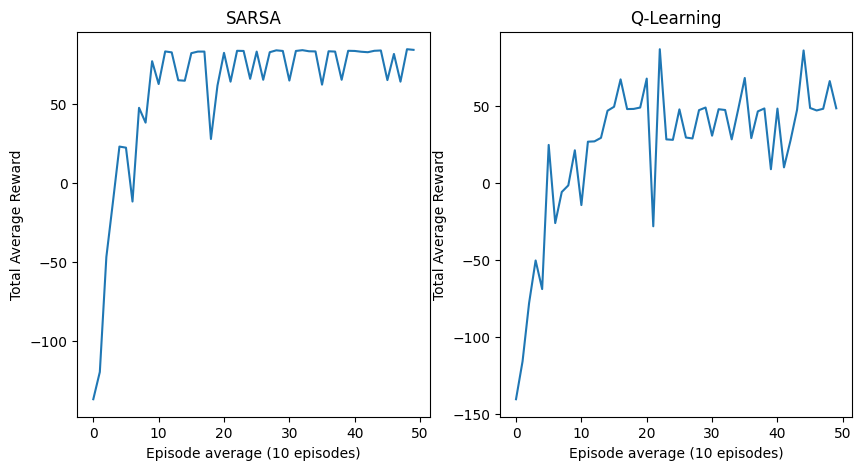

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot([np.average(Q_saer_rewards[index:index+10]) for index in range(0, len(Q_saer_rewards), 10)])
axes[0].set_xlabel('Episode average (10 episodes)')
axes[0].set_ylabel('Total Average Reward')
axes[0].set_title('SARSA')

axes[1].plot([np.average(Q_learn_rewards[index:index+10]) for index in range(0, len(Q_learn_rewards), 10)])
axes[1].set_xlabel('Episode average (10 episodes)')
axes[1].set_ylabel('Total Average Reward')
axes[1].set_title('Q-Learning')

plt.show()

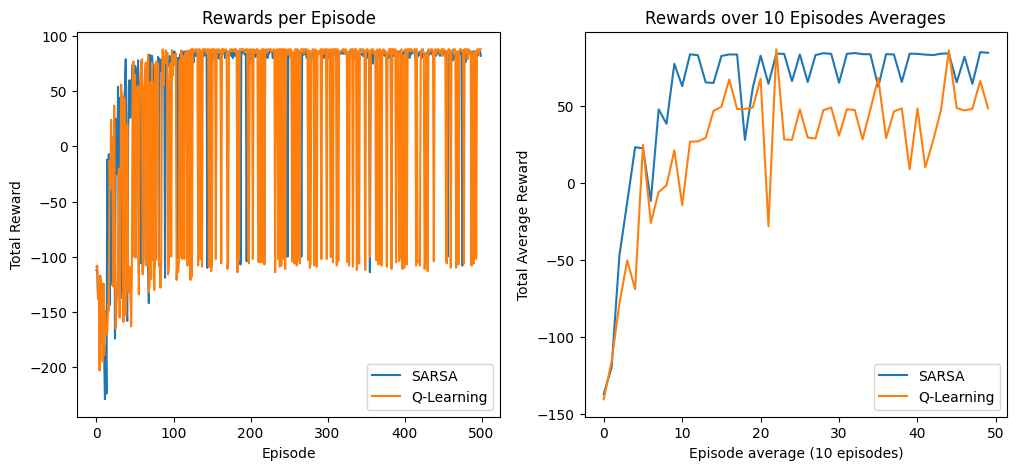

In [98]:
plot_sear_and_q_learning_rewards(Q_saer_rewards, Q_learn_rewards)

In [99]:
Q_learn_policy = agent.extract_policy(Q_learn_values)
print("Q-Learning Policy:")
print(Q_learn_policy)

Q-Learning Policy:
[[1 0 2 3 1 1 1 1 0 0 0 1]
 [1 1 1 1 3 1 3 1 1 1 3 1]
 [3 3 3 3 3 3 3 3 3 3 3 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


In [100]:
agent.print_policy(Q_learn_policy)

↓ ↑ ← → ↓ ↓ ↓ ↓ ↑ ↑ ↑ ↓ 
↓ ↓ ↓ ↓ → ↓ → ↓ ↓ ↓ → ↓ 
→ → → → → → → → → → → ↓ 
S C C C C C C C C C C G 


In [101]:
Q_saer_policy = agent.extract_policy(Q_saer_values)
print("SARSA Policy:")
print(Q_saer_policy)

SARSA Policy:
[[1 1 1 1 1 3 1 1 1 1 1 1]
 [3 3 3 3 3 3 3 3 3 3 3 1]
 [0 3 0 0 0 0 0 3 0 0 3 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


In [102]:
agent.print_policy(Q_saer_policy)

↓ ↓ ↓ ↓ ↓ → ↓ ↓ ↓ ↓ ↓ ↓ 
→ → → → → → → → → → → ↓ 
↑ → ↑ ↑ ↑ ↑ ↑ → ↑ ↑ → ↓ 
S C C C C C C C C C C G 


# Question time! :D

1. Which algorithm learns a shorter path in the final greedy policy? Which algorithm obtains a larger cumulative sum during training?

The algorithm that learns a shorter path is Q-learning because it updates based on the best possible action, while SARSA updates based on the action taken by the agent, which may not always be the best action. About the cumulative sum: in our test they bouth get the maximum, however, the real answer depends on the environment. If the environment is deterministic then Q-learning will obtain a larger sum faster than SARSA, but if the environment is stochastic then SARSA may obtain a larger sum because it explores more.

2. Why do the two algorithms converge to different policies?

The algorithms converge to different policies because there is not a single policy that has the maximum cumulative reward. Then the off-policy algorithm always converges to the optimal policy, while the on-policy algorithm may converge to a suboptimal policy depending on the actions taken by the agent during training. So SARSA will have a different path after every run.

3. Why is there no contradiction between the first and the second question?

There is no contradiction between the first and the second question because the first question is about the path learned by the algorithm, while the second question is about the policy learned by the algorithm. The path learned by the algorithm may be shorter, but the policy learned by the algorithm may not be optimal.

---

# Challenges!

### Change the reward function
First, let's think about this. No copilot, no nothing... If we changed epsilon to basically 0 then the agent should allways take the action with the highest Q-value, which means that it will always take the same path.

But this wasn't the challenge. I'm thinking, what can I change? Well the normal reward. The instinct is that changing the basic reward to be a bigger negative number then they will try not to explore, another thought is: what if the reward is positive? 

In [103]:
challange_agent_neg = CliffWalkingEnv(normal_step_reward=-10)
Q_saer_values_neg, Q_saer_rewards_neg = challange_agent_neg.sarsa_update(episodes=500)
Q_learn_values_neg, Q_learn_rewards_neg = challange_agent_neg.q_learning_update(episodes=500)

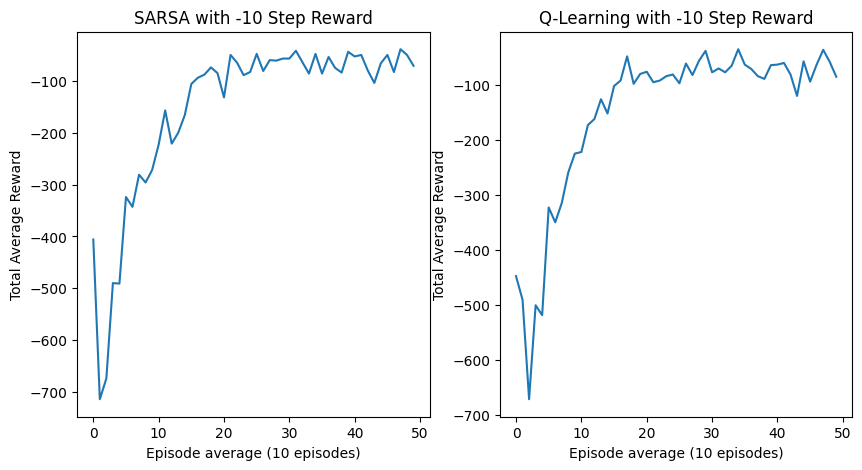

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot([np.average(Q_saer_rewards_neg[index:index+10]) for index in range(0, len(Q_saer_rewards_neg), 10)])
axes[0].set_xlabel('Episode average (10 episodes)')
axes[0].set_ylabel('Total Average Reward')
axes[0].set_title('SARSA with -10 Step Reward')

axes[1].plot([np.average(Q_learn_rewards_neg[index:index+10]) for index in range(0, len(Q_learn_rewards_neg), 10)])
axes[1].set_xlabel('Episode average (10 episodes)')
axes[1].set_ylabel('Total Average Reward')
axes[1].set_title('Q-Learning with -10 Step Reward')

plt.show()

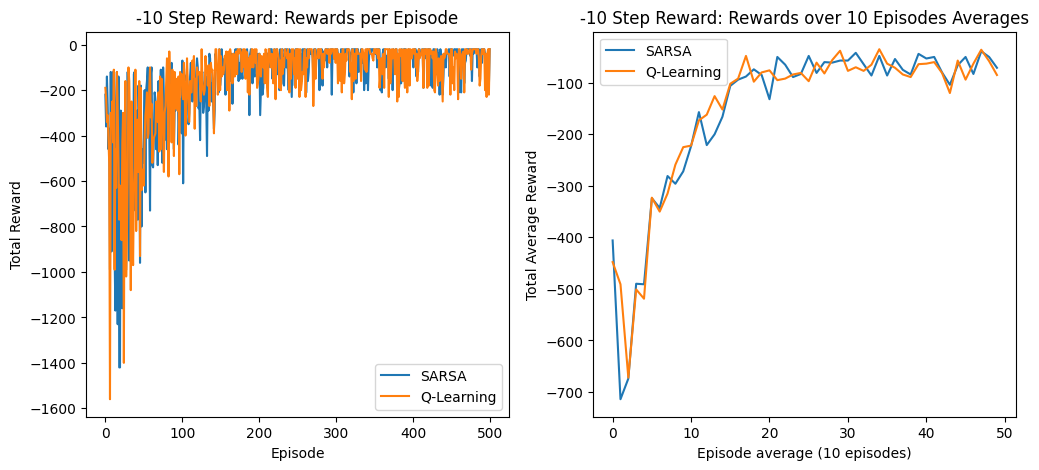

In [105]:
plot_sear_and_q_learning_rewards(Q_saer_rewards_neg, Q_learn_rewards_neg, label_prefix='-10 Step Reward: ')

In [106]:
print("\nSARSA Policy with -20 Step Reward:")
challange_agent_neg.print_policy(challange_agent_neg.extract_policy(Q_saer_values_neg))
print("\nQ-Learning Policy with -20 Step Reward:")
challange_agent_neg.print_policy(challange_agent_neg.extract_policy(Q_learn_values_neg))


SARSA Policy with -20 Step Reward:
← → → → ↓ → → ↓ → ↓ ↓ ↓ 
→ → → ↓ → → → ↓ → ↓ ↓ ↓ 
→ → → → → → → → → → → ↓ 
S C C C C C C C C C C G 

Q-Learning Policy with -20 Step Reward:
↑ → ↑ → → ↑ ↓ ↓ ← ↓ ↓ ↓ 
↓ ↓ ↓ → ↓ ↓ → ↓ ↓ ↓ ↓ ↓ 
→ → → → → → → → → → → ↓ 
S C C C C C C C C C C G 


In [107]:
challange_agent_poz = CliffWalkingEnv(normal_step_reward=20)
Q_saer_values_poz, Q_saer_rewards_poz = challange_agent_poz.sarsa_update(episodes=50)
Q_learn_values_poz, Q_learn_rewards_poz = challange_agent_poz.q_learning_update(episodes=50)

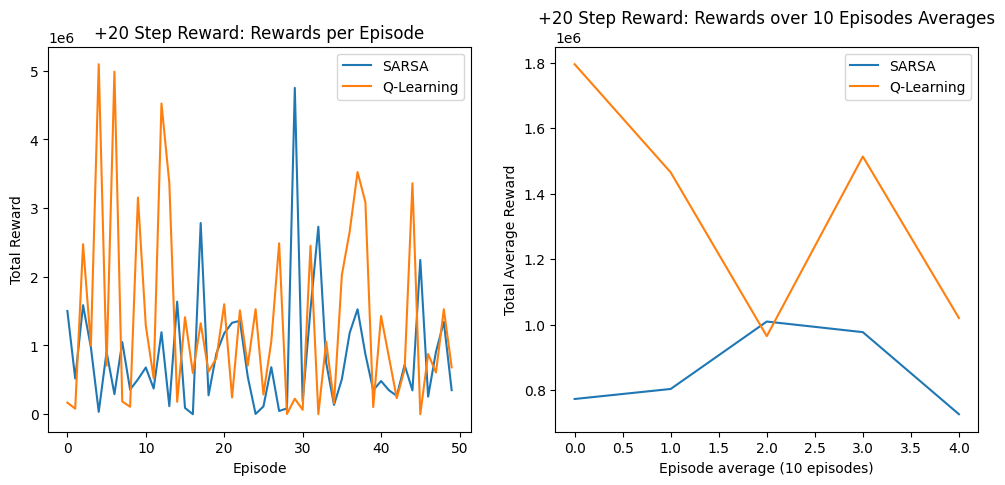

In [108]:
plot_sear_and_q_learning_rewards(Q_saer_rewards_poz, Q_learn_rewards_poz, label_prefix='+20 Step Reward: ')

To be expected, makeing the normal step reward more negative makes the agent more cautious and less likely to explore, while making it positive encourages the agent to explore more.

### Change epsilon

Well here we have two **main questions:** what if we make epsilon 0? Well the answer is that the agent will always take the action with the highest Q-value, which means that it will always take the same path. What if we make epsilon 1? The answer is that the agent will always take a random action, which means that it will explore more and it will **not learn anything**.

Now let's see how we can model a epsilon schedule that chnages based on how far we are on the grid.

In [109]:
Q_saer_values_decay, Q_saer_rewards_decay = CliffWalkingEnv(decay=True).sarsa_update(episodes=500)

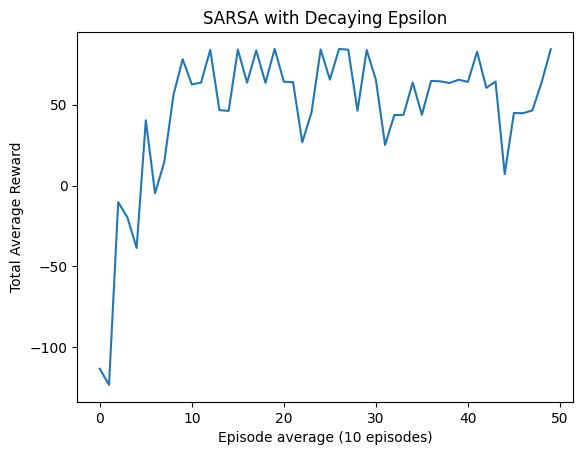

In [111]:
plt.plot([np.average(Q_saer_rewards_decay[index:index+10]) for index in range(0, len(Q_saer_rewards_decay), 10)])
plt.xlabel('Episode average (10 episodes)')
plt.ylabel('Total Average Reward')
plt.title('SARSA with Decaying Epsilon')
plt.show()

# Last round of questions!

1. What happens if you set ε = 0 from the start for Q-learning? But for SARSA? Why?

Q-learning becomes fully greedy from the beginning. Learning can become stuck in a suboptimal policy. The algorithm may fail to discover the optimal route entirely. SARSA may converge to whatever initial path was accidentally selected. In the end the distinction between SARSA and Q-learning becomes much smaller, as both algorithms will be more likely to converge to a suboptimal policy.

2. If γ < 1 (e.g. γ = 0.9), how does each algorithm's preference for the short path vs. the safe path change? Give your reasons.

Gamma is how much the agent cares about future rewards compared to immediate rewards. If gamma is less than 1, the agent will prefer the short path because it will receive a higher reward sooner. The safe path may have a higher cumulative reward, but that don't matter. If gamma is 1 then the current rewaed is as important as the future one.

3. Give a real-world example (not grid game) where you would prefer SARSA over Q-learning and explain why.

Ok, here I think there are a lot of examples, but let me tell you what i came up with. Let's imagine that only SARSA and Q-learning existed, because only thous two algorithms i know.

**LIVE TRADING**: in live trading the market is a stochastic environment, and the agent needs to learn a policy that takes into account the actions it takes in the next state. If we use Q-learning, the agent may learn a policy that is optimal for a deterministic environment, but it may not perform well in a stochastic environment. Also having risk invalved, we are playing with money, so we would wan't a safer algorithm that takes into account the actions taken by the agent in the next state, which is what SARSA does.

Now if we were to use this in real life i think better would be to make the Q-values with with Q-learning using old data, and then use SARSA to update the Q-values in real time as the agent interacts with the environment. This way we can have the best of both worlds: we can learn a good policy from historical data, and then we can adapt that policy in real time as the market changes.

<dr>

__IF THIS ANSWER IS WRONG THAN I DIDN'T MEAN IT, I ACTUALY WROTE SELF-DRAVING CARS, BUT IT GOTE CHNAGED BY THE SPELL CHECKER__